created 6/26/26 for exploring hits data from minibwa

# June 26, 2026
* ran minibwa on small read ERR9860257

In [2]:
import subprocess
import pandas as pd

SAMTOOLS = "/home/hua575/miniconda3/envs/minibwa/bin/samtools"  

# Run idxstats and read into pandas
result = subprocess.run(
    [SAMTOOLS, "idxstats", "ERR9860257.bam"],
    capture_output=True, text=True
)

df = pd.read_csv(
    pd.io.common.StringIO(result.stdout),
    sep="\t",
    header=None,
    names=["is_element", "length", "mapped_reads", "unmapped_reads"]
)

# Drop the last row (samtools adds a "*" catch-all line)
df = df[df["is_element"] != "*"]

# Sort by hits
df = df.sort_values("mapped_reads", ascending=False)

In [ ]:
import matplotlib.pyplot as plt

# Top 20 IS elements
top = df[df["mapped_reads"] > 0].head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top["is_element"], top["mapped_reads"])
ax.invert_yaxis()
ax.set_xlabel("Mapped reads")
ax.set_title("ERR9860257 — IS element hit counts")
plt.tight_layout()
plt.show()

In [3]:
from Bio import SeqIO
import pandas as pd

def parse_gbff(gbff_path: str) -> pd.DataFrame:
    """
    Extract gene features from a GenBank flat file.
    Returns a DataFrame with one row per gene.
    """
    records = []
    
    for record in SeqIO.parse(gbff_path, "genbank"):
        for feature in record.features:
            if feature.type != "gene":
                continue
            
            qualifiers = feature.qualifiers
            records.append({
                "chrom":      record.id,
                "start":      int(feature.location.start),  # 0-based
                "end":        int(feature.location.end),
                "strand":     "+" if feature.location.strand == 1 else "-",
                "gene":       qualifiers.get("gene", ["unknown"])[0],
                "locus_tag":  qualifiers.get("locus_tag", ["unknown"])[0],
                "product":    qualifiers.get("product", ["unknown"])[0],
            })
    
    return pd.DataFrame(records)

genes = parse_gbff("../ismapper/ncbi_dataset/data/GCF_000005845.2/GCF_000005845.2_no_IS.gbff")

In [4]:
# Parse insertion_sites.bam to get genomic coordinates
import pysam

records = []
with pysam.AlignmentFile("insertion_sites.bam", "rb") as bam:
    for read in bam.fetch():
        if read.is_unmapped:
            continue
        name_parts = read.query_name.split("|")
        records.append({
            "read_name":  name_parts[0],
            "is_element": name_parts[1],
            "is_pos":     name_parts[2],
            "clip_side":  name_parts[3],
            "chrom":      read.reference_name,
            "genome_pos": read.reference_start,
            "mapq":       read.mapping_quality,
        })

sites = pd.DataFrame(records)

In [5]:
def find_gene(chrom: str, pos: int, genes: pd.DataFrame) -> dict:
    """Find which gene (if any) a genomic position falls in."""
    hits = genes[
        (genes["chrom"] == chrom) &
        (genes["start"] <= pos) &
        (genes["end"]   >= pos)
    ]
    if hits.empty:
        return {"gene": "intergenic", "locus_tag": None, "strand": None, "product": None}
    # if overlaps multiple (nested features), return all
    return hits.iloc[0].to_dict()

# Apply to every insertion site
gene_hits = sites.apply(
    lambda row: pd.Series(find_gene(row["chrom"], row["genome_pos"], genes)),
    axis=1
)

results = pd.concat([sites, gene_hits], axis=1)

In [6]:
results[results["gene"] != "intergenic"] \
    .groupby(["gene", "locus_tag", "product"]) \
    .size() \
    .reset_index(name="supporting_reads") \
    .sort_values("supporting_reads", ascending=False)

,gene,locus_tag,product,supporting_reads
6,yaiS,b0364,unknown,145
1,prpE,b0335,unknown,27
4,sfmD,b0532,unknown,8
0,cusA,b0575,unknown,5
3,sfmA,b0530,unknown,4
8,ybfQ,b4514,unknown,4
2,rhsE,b1456,unknown,2
5,yadL,b0137,unknown,1
7,ybeQ,b0644,unknown,1
9,ydcD,b1457,unknown,1


# June 30, 2026
* read in the .bam file for ERR9860257.bam which mapped reads to ISfinder DB

In [5]:
# finding the average length of ISs in ISfinder DB

avg_length = df['length'].mean()
print(avg_length)

1478.2299645689218


In [7]:
import pandas as pd
import pysam

bamfile = pysam.AlignmentFile("ERR9860257.bam", "rb")

records = []
for read in bamfile:
    records.append({
        "query_name": read.query_name,
        "reference_name": read.reference_name,
        "reference_start": read.reference_start,
        "reference_end": read.reference_end,
        "cigar": read.cigarstring,
        "mapq": read.mapping_quality,
        "is_unmapped": read.is_unmapped,
        "is_secondary": read.is_secondary,
        "is_supplementary": read.is_supplementary,
        "flag": read.flag,
    })

bamfile.close()
bamfile_df = pd.DataFrame(records)
bamfile_df.head()

,query_name,reference_name,reference_start,reference_end,cigar,mapq,is_unmapped,is_secondary,is_supplementary,flag
0,ERR9860257.8752,ISEc17,0,204,46S204M,20,False,False,False,163
1,ERR9860257.28335,ISEc17,0,218,33S218M,20,False,False,False,163
2,ERR9860257.29877,ISEc17,0,227,23S227M,20,False,False,False,163
3,ERR9860257.37536,ISEc17,0,234,15S234M,20,False,False,False,99
4,ERR9860257.40859,ISEc17,0,222,28S222M,20,False,False,False,99


# July 1, 2026
* fastq file of reads --> minibwa align to ISfinder DB --> for every IS extract overhangs and A.v.A. cluster

In [1]:
# how similar is the isfinder DB?
import pandas as pd
isfinder_DB = pd.read_csv("../isfinder/isfinder_diversity.tsv", sep="\t", names=["query", "target", "pident", "alnlen", "qcov", "tcov", "evalue", "bits"])

In [2]:
n_total = len(isfinder_DB)
self_hits = isfinder_DB[isfinder_DB["query"] == isfinder_DB["target"]]
non_self = isfinder_DB[isfinder_DB["query"] != isfinder_DB["target"]]
print(f"total rows: {n_total}, self-hits: {len(self_hits)}, non-self: {len(non_self)}")
print(non_self["pident"].describe())
print(len(non_self[non_self["pident"]>99]))

total rows: 22714, self-hits: 5924, non-self: 16790
count    16790.000000
mean        78.882424
std          8.155788
min         62.900000
25%         72.500000
50%         77.200000
75%         84.600000
max        100.000000
Name: pident, dtype: float64
266


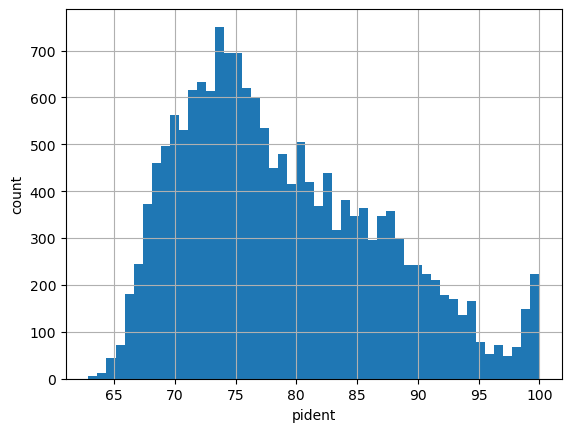

0.10    69.3
0.25    72.5
0.50    77.2
0.75    84.6
0.90    90.6
0.99    99.4
Name: pident, dtype: float64


In [3]:
import matplotlib.pyplot as plt
non_self["pident"].hist(bins=50)
plt.xlabel("pident"); plt.ylabel("count")
plt.show()

print(non_self["pident"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.99]))

# July 2, 2026
* collapse isfinder DB (collapse seqs with 99+ perid)
* aligning batch 1 (560 fastqs) to IS and cluster

In [6]:
import pandas as pd
import networkx as nx
from Bio import SeqIO
import random

random.seed(42)  # reproducibility — change/remove if you want true randomness per run

# --- inputs ---
tsv_path = "../isfinder/isfinder_diversity.tsv"
fasta_path = "../ISfinder_database-master_2026/IS.database.fa"
out_fasta = "../ISfinder_database-master_2026/IS.database.collapsed99.fa"
out_map = "../ISfinder_database-master_2026/IS.database.collapsed99.mapping.tsv"

# --- load pairwise hits ---
df = pd.read_csv(tsv_path, sep="\t",
                  names=["query", "target", "pident", "alnlen", "qcov", "tcov", "evalue", "bits"])

# drop self-hits, keep only >=99% identity edges
df = df[df["query"] != df["target"]]
edges = df[df["pident"] >= 99.0]

# --- load all sequence IDs from fasta (so singletons with no >=99% edge are preserved) ---
records = {rec.id: rec for rec in SeqIO.parse(fasta_path, "fasta")}
all_ids = set(records.keys())

# --- build graph: nodes = all IS entries, edges = >=99% pident pairs ---
G = nx.Graph()
G.add_nodes_from(all_ids)
for _, row in edges.iterrows():
    if row["query"] in all_ids and row["target"] in all_ids:
        G.add_edge(row["query"], row["target"], pident=row["pident"])

# --- connected components = clusters ---
clusters = list(nx.connected_components(G))

rep_records = []
mapping_rows = []

for i, cluster in enumerate(clusters):
    cluster = list(cluster)
    rep = random.choice(cluster)  # random representative, as requested
    rep_records.append(records[rep])

    # diagnostic: min pident observed within this cluster's edges (chaining check)
    if len(cluster) > 1:
        sub_edges = edges[edges["query"].isin(cluster) & edges["target"].isin(cluster)]
        min_pident_in_cluster = sub_edges["pident"].min() if not sub_edges.empty else None
    else:
        min_pident_in_cluster = None  # singleton

    for member in cluster:
        mapping_rows.append({
            "cluster_id": f"cluster_{i}",
            "member_id": member,
            "representative_id": rep,
            "cluster_size": len(cluster),
            "min_pident_within_cluster": min_pident_in_cluster
        })

# --- write outputs ---
SeqIO.write(rep_records, out_fasta, "fasta")

map_df = pd.DataFrame(mapping_rows)
map_df.to_csv(out_map, sep="\t", index=False)

print(f"Total input sequences: {len(all_ids)}")
print(f"Clusters (>=99% pident, connected components): {len(clusters)}")
print(f"Representatives written to: {out_fasta}")
print(f"Mapping written to: {out_map}")

# QC flag: clusters where chaining likely produced a misleading merge
suspect = map_df[(map_df["min_pident_within_cluster"].notna()) &
                  (map_df["min_pident_within_cluster"] < 99.0)]
n_suspect_clusters = suspect["cluster_id"].nunique()
print(f"Clusters with internal pident dropping below 99% (chaining artifacts): {n_suspect_clusters}")

Total input sequences: 5927
Clusters (>=99% pident, connected components): 5804
Representatives written to: ../ISfinder_database-master_2026/IS.database.collapsed99.fa
Mapping written to: ../ISfinder_database-master_2026/IS.database.collapsed99.mapping.tsv
Clusters with internal pident dropping below 99% (chaining artifacts): 0


# July 9, 2026

In [ ]:
# issue: bwa ran, generated bam files and thus deleted the fastq files, but then a task within the job failed, 
# removing all generated bam files, but since the fastq files were deleted and the layout file exists, the next time 
# bwa was called, snakemake fails
# fix this issue, but removing the layout file if the corresponding fastq files do no exist
# script generated --> remove_layout.sh

# July 10, 2026
* look through ISOSDB, cluster with itself and ISfinder to see similarities/differences

In [6]:
# comparing ISOSDB through interal clustering

import pandas as pd
import networkx as nx
from Bio import SeqIO
import random

random.seed(42)  # reproducibility — change/remove if you want true randomness per run

# --- inputs ---
tsv_path = "../pseudoR/isosdb_self.tsv"
fasta_path = "../pseudoR/ISOSDB.V3.fna"
# out_fasta = "../pseudoR/ISOSDB.V3.collapsed.fna"
# out_map = "../pseudoR/ISOSDB.V3.collapsed.map.tsv"

# --- load pairwise hits ---
self_df = pd.read_csv(tsv_path, sep="\t",
                  names=["query", "target", "pident", "alnlen", "qcov", "tcov", "evalue", "bits"])

# drop self-hits, keep only >=99% identity edges
self_df = self_df[self_df["query"] != self_df["target"]]
edges = self_df[self_df["pident"] >= 99.0]

# --- load all sequence IDs from fasta (so singletons with no >=99% edge are preserved) ---
records = {rec.id: rec for rec in SeqIO.parse(fasta_path, "fasta")}
all_ids = set(records.keys())

# --- build graph: nodes = all IS entries, edges = >=99% pident pairs ---
G = nx.Graph()
G.add_nodes_from(all_ids)
for _, row in edges.iterrows():
    if row["query"] in all_ids and row["target"] in all_ids:
        G.add_edge(row["query"], row["target"], pident=row["pident"])

# --- connected components = clusters ---
clusters = list(nx.connected_components(G))

rep_records = []
mapping_rows = []

for i, cluster in enumerate(clusters):
    cluster = list(cluster)
    rep = random.choice(cluster)  # random representative, as requested
    rep_records.append(records[rep])

    # diagnostic: min pident observed within this cluster's edges (chaining check)
    if len(cluster) > 1:
        sub_edges = edges[edges["query"].isin(cluster) & edges["target"].isin(cluster)]
        min_pident_in_cluster = sub_edges["pident"].min() if not sub_edges.empty else None
    else:
        min_pident_in_cluster = None  # singleton

    for member in cluster:
        mapping_rows.append({
            "cluster_id": f"cluster_{i}",
            "member_id": member,
            "representative_id": rep,
            "cluster_size": len(cluster),
            "min_pident_within_cluster": min_pident_in_cluster
        })

# --- write outputs ---
# SeqIO.write(rep_records, out_fasta, "fasta")

map_df = pd.DataFrame(mapping_rows)
# map_df.to_csv(out_map, sep="\t", index=False)

print(f"Total input sequences: {len(all_ids)}")
print(f"Clusters (>=99% pident, connected components): {len(clusters)}")
# print(f"Representatives written to: {out_fasta}")
# print(f"Mapping written to: {out_map}")

# QC flag: clusters where chaining likely produced a misleading merge
suspect = map_df[(map_df["min_pident_within_cluster"].notna()) &
                  (map_df["min_pident_within_cluster"] < 99.0)]
n_suspect_clusters = suspect["cluster_id"].nunique()
print(f"Clusters with internal pident dropping below 99% (chaining artifacts): {n_suspect_clusters}")

Total input sequences: 22713
Clusters (>=99% pident, connected components): 22656
Clusters with internal pident dropping below 99% (chaining artifacts): 0


In [1]:
# comparing ISOSDB by clustering against ISfinder DB

import pandas as pd
import networkx as nx
from Bio import SeqIO
import random

random.seed(42)  # reproducibility — change/remove if you want true randomness per run

# --- inputs ---
tsv_path = "../pseudoR/isosdb_isfinder.tsv"
fasta_path = "../pseudoR/ISOSDB.V3.fna"
# out_fasta = "../pseudoR/ISOSDB.V3.collapsed.fna"
# out_map = "../pseudoR/ISOSDB.V3.collapsed.map.tsv"

# --- load pairwise hits ---
compare_df = pd.read_csv(tsv_path, sep="\t",
                  names=["query", "target", "pident", "alnlen", "qcov", "tcov", "evalue", "bits"])

# drop self-hits, keep only >=99% identity edges
compare_df = compare_df[compare_df["query"] != compare_df["target"]]
edges = compare_df[compare_df["pident"] >= 99.0]

# --- load all sequence IDs from fasta (so singletons with no >=99% edge are preserved) ---
records = {rec.id: rec for rec in SeqIO.parse(fasta_path, "fasta")}
all_ids = set(records.keys())

# --- build graph: nodes = all IS entries, edges = >=99% pident pairs ---
G = nx.Graph()
G.add_nodes_from(all_ids)
for _, row in edges.iterrows():
    if row["query"] in all_ids and row["target"] in all_ids:
        G.add_edge(row["query"], row["target"], pident=row["pident"])

# --- connected components = clusters ---
clusters = list(nx.connected_components(G))

rep_records = []
mapping_rows = []

for i, cluster in enumerate(clusters):
    cluster = list(cluster)
    rep = random.choice(cluster)  # random representative, as requested
    rep_records.append(records[rep])

    # diagnostic: min pident observed within this cluster's edges (chaining check)
    if len(cluster) > 1:
        sub_edges = edges[edges["query"].isin(cluster) & edges["target"].isin(cluster)]
        min_pident_in_cluster = sub_edges["pident"].min() if not sub_edges.empty else None
    else:
        min_pident_in_cluster = None  # singleton

    for member in cluster:
        mapping_rows.append({
            "cluster_id": f"cluster_{i}",
            "member_id": member,
            "representative_id": rep,
            "cluster_size": len(cluster),
            "min_pident_within_cluster": min_pident_in_cluster
        })

# --- write outputs ---
# SeqIO.write(rep_records, out_fasta, "fasta")

map_df = pd.DataFrame(mapping_rows)
# map_df.to_csv(out_map, sep="\t", index=False)

print(f"Total input sequences: {len(all_ids)}")
print(f"Clusters (>=99% pident, connected components): {len(clusters)}")
# print(f"Representatives written to: {out_fasta}")
# print(f"Mapping written to: {out_map}")

# QC flag: clusters where chaining likely produced a misleading merge
suspect = map_df[(map_df["min_pident_within_cluster"].notna()) &
                  (map_df["min_pident_within_cluster"] < 99.0)]
n_suspect_clusters = suspect["cluster_id"].nunique()
print(f"Clusters with internal pident dropping below 99% (chaining artifacts): {n_suspect_clusters}")

Total input sequences: 22713
Clusters (>=99% pident, connected components): 22713
Clusters with internal pident dropping below 99% (chaining artifacts): 0


In [8]:
isfinder_db = pd.read_csv("../ISfinder_database-master_2026/IS.database.collapsed99.mapping.tsv")

# July 13, 2026
* Clustering overhangs

In [9]:
import pandas as pd

SRR8456430_ISEc8_left_clustered = pd.read_csv("/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430_ISEc8_left_clustered.tsv", sep='\t',
                                              names=["query", "target", "pident", "alnlen", "qcov", "tcov", "evalue", "bits"])
n_clusters_convertalis = SRR8456430_ISEc8_left_clustered["query"].nunique()
print(f"Clusters: {n_clusters_convertalis}")

Clusters: 449


In [10]:
SRR8456430_ISEc8_left_clustered.head(10)

,query,target,pident,alnlen,qcov,tcov,evalue,bits
0,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,100.0,97,1.0,1.000,1.194000e-51,175
1,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.585638|ISEc8|pos:0|side:...,100.0,97,1.0,1.000,1.194000e-51,175
2,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.774632|ISEc8|pos:0|side:...,100.0,97,1.0,0.960,1.194000e-51,175
3,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.225086|ISEc8|pos:0|side:...,100.0,97,1.0,0.890,1.194000e-51,175
4,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.487564|ISEc8|pos:0|side:...,100.0,97,1.0,0.808,1.194000e-51,175
5,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.487564|ISEc8|pos:0|side:...,100.0,97,1.0,0.808,1.194000e-51,175
6,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.317109|ISEc8|pos:0|side:...,100.0,97,1.0,0.789,1.194000e-51,175
7,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.981731|ISEc8|pos:0|side:...,100.0,97,1.0,0.782,1.194000e-51,175
8,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.201710|ISEc8|pos:0|side:...,100.0,97,1.0,0.776,1.194000e-51,175
9,SRR8456430|SRR8456430.531150|ISEc8|pos:0|side:...,SRR8456430|SRR8456430.39909|ISEc8|pos:0|side:l...,100.0,97,1.0,0.735,1.194000e-51,175


In [ ]:
mem_cols = ["representative", "member"]
mem = pd.read_csv("/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430_ISEc8_left_clustered_rep.tsv", sep="\t", header=None, names=mem_cols)

n_clusters_total = mem["representative"].nunique()
n_singletons = (mem.groupby("representative")["member"].size() == 1).sum()

print(f"Total clusters (createtsv, includes singletons): {n_clusters_total}")
print(f"Singleton clusters: {n_singletons} ({n_singletons/n_clusters_total:.1%} of clusters)")

Total clusters (createtsv, includes singletons): 34
Singleton clusters: 19 (55.9% of clusters)


In [8]:
mem.head(10)

representative  \
SRR8456430|SRR8456430.149485|ISEc8|pos:0|side:l... SRR8456430|SRR8456430.149485|ISEc8|pos:0|side:l... 195 1.00 6.994000e-58 0 107 108 0  107 108 0 107               0   
                                                   SRR8456430|SRR8456430.532085|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 5  112 113 0 107               0   
                                                   SRR8456430|SRR8456430.201438|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 7  114 115 0 107               0   
                                                   SRR8456430|SRR8456430.222839|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 15 122 123 0 107               0   
                                                   SRR8456430|SRR8456430.786436|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 35 142 143 0 107               0   
                                                   SRR8456430|SRR8456430.786436|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 35 142 143 0 107               0   
                                                   SRR8456430|SRR8456430.636427|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 39 146 147 0 107               0   
                                                   SRR8456430|SRR8456430.297979|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 66 173 174 0 107               0   
                                                   SRR8456430|SRR8456430.578051|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 67 174 175 0 107               0   
                                                   SRR8456430|SRR8456430.617846|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 71 178 179 0 107               0   

                                                                                                                                                        member  
SRR8456430|SRR8456430.149485|ISEc8|pos:0|side:l... SRR8456430|SRR8456430.149485|ISEc8|pos:0|side:l... 195 1.00 6.994000e-58 0 107 108 0  107 108 0 107       0  
                                                   SRR8456430|SRR8456430.532085|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 5  112 113 0 107       0  
                                                   SRR8456430|SRR8456430.201438|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 7  114 115 0 107       0  
                                                   SRR8456430|SRR8456430.222839|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 15 122 123 0 107       0  
                                                   SRR8456430|SRR8456430.786436|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 35 142 143 0 107       0  
                                                   SRR8456430|SRR8456430.786436|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 35 142 143 0 107       0  
                                                   SRR8456430|SRR8456430.636427|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 39 146 147 0 107       0  
                                                   SRR8456430|SRR8456430.297979|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 66 173 174 0 107       0  
                                                   SRR8456430|SRR8456430.578051|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 67 174 175 0 107       0  
                                                   SRR8456430|SRR8456430.617846|ISEc8|pos:0|side:l... 191 0.99 3.573000e-56 0 107 108 71 178 179 0 107       0

In [12]:
import polars as pl
clu = pl.read_csv(
    "/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430_ISEc8_left_clu_cluster.tsv",
    separator="\t",
    has_header=False,
    new_columns=["representative_id", "member_id"],
)

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 56.0      │
│ null_count ┆ 0.0       │
│ mean       ┆ 8.875     │
│ std        ┆ 17.928203 │
│ min        ┆ 1.0       │
│ 25%        ┆ 1.0       │
│ 50%        ┆ 1.0       │
│ 75%        ┆ 2.0       │
│ max        ┆ 64.0      │
└────────────┴───────────┘

Total clusters: 56
Total overhangs: 497
Singleton clusters (size 1): 34


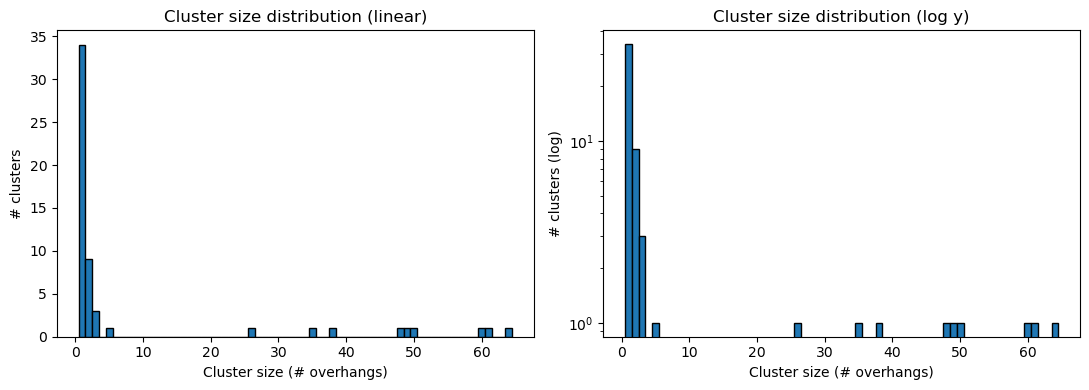

In [1]:
import polars as pl
import matplotlib.pyplot as plt

# clu = pl.read_csv(
#     "/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430_ISEc8_left_clu_cluster.tsv",
#     separator="\t",
#     has_header=False,
#     new_columns=["representative_id", "member_id"],
# )
clu = pl.read_csv(
    "/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430_ISEc8_left_clu_2_cluster.tsv",
    separator="\t",
    has_header=False,
    new_columns=["representative_id", "member_id"],
)

cluster_sizes = (
    clu.group_by("representative_id")
    .len()
    .rename({"len": "cluster_size"})
)

print(cluster_sizes["cluster_size"].describe())
print(f"\nTotal clusters: {cluster_sizes.height}")
print(f"Total overhangs: {clu.height}")
print(f"Singleton clusters (size 1): {(cluster_sizes['cluster_size'] == 1).sum()}")

sizes = cluster_sizes["cluster_size"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(sizes, bins=range(1, sizes.max() + 2), edgecolor="black", align="left")
axes[0].set_xlabel("Cluster size (# overhangs)")
axes[0].set_ylabel("# clusters")
axes[0].set_title("Cluster size distribution (linear)")

axes[1].hist(sizes, bins=range(1, sizes.max() + 2), edgecolor="black", align="left")
axes[1].set_yscale("log")
axes[1].set_xlabel("Cluster size (# overhangs)")
axes[1].set_ylabel("# clusters (log)")
axes[1].set_title("Cluster size distribution (log y)")

plt.tight_layout()
# plt.savefig("SRR8456430_ISEc8_left_cluster_size_dist.png", dpi=150)
plt.show()

# July 14, 2026
* more testing on clustering

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 18.0      │
│ null_count ┆ 0.0       │
│ mean       ┆ 9.5       │
│ std        ┆ 25.189283 │
│ min        ┆ 1.0       │
│ 25%        ┆ 1.0       │
│ 50%        ┆ 1.0       │
│ 75%        ┆ 1.0       │
│ max        ┆ 95.0      │
└────────────┴───────────┘

Total clusters: 18
Total overhangs: 171
Singleton clusters (size 1): 14


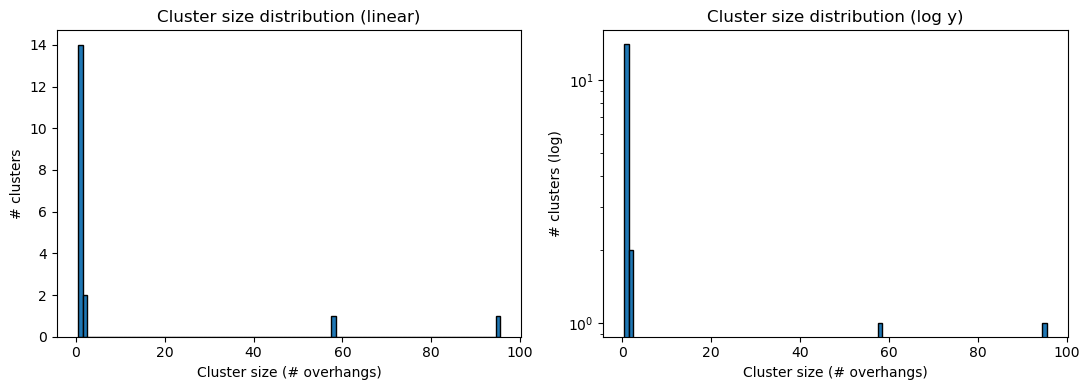

In [2]:
import polars as pl
import matplotlib.pyplot as plt

clu = pl.read_csv(
    "/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430__ISEc31__left/SRR8456430__ISEc31__left_clu_cluster.tsv",
    separator="\t",
    has_header=False,
    new_columns=["representative_id", "member_id"],
)
# clu = pl.read_csv(
#     "/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430_ISEc8_left_clu_2_cluster.tsv",
#     separator="\t",
#     has_header=False,
#     new_columns=["representative_id", "member_id"],
# )

cluster_sizes = (
    clu.group_by("representative_id")
    .len()
    .rename({"len": "cluster_size"})
)

print(cluster_sizes["cluster_size"].describe())
print(f"\nTotal clusters: {cluster_sizes.height}")
print(f"Total overhangs: {clu.height}")
print(f"Singleton clusters (size 1): {(cluster_sizes['cluster_size'] == 1).sum()}")

sizes = cluster_sizes["cluster_size"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(sizes, bins=range(1, sizes.max() + 2), edgecolor="black", align="left")
axes[0].set_xlabel("Cluster size (# overhangs)")
axes[0].set_ylabel("# clusters")
axes[0].set_title("Cluster size distribution (linear)")

axes[1].hist(sizes, bins=range(1, sizes.max() + 2), edgecolor="black", align="left")
axes[1].set_yscale("log")
axes[1].set_xlabel("Cluster size (# overhangs)")
axes[1].set_ylabel("# clusters (log)")
axes[1].set_title("Cluster size distribution (log y)")

plt.tight_layout()
# plt.savefig("SRR8456430_ISEc8_left_cluster_size_dist.png", dpi=150)
plt.show()

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

clu = pl.read_csv(
    "/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430__ISEc31__left/SRR8456430__ISEc31__left_clu_cluster.tsv",
    separator="\t",
    has_header=False,
    new_columns=["representative_id", "member_id"],
)
# clu = pl.read_csv(
#     "/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430_ISEc8_left_clu_2_cluster.tsv",
#     separator="\t",
#     has_header=False,
#     new_columns=["representative_id", "member_id"],
# )

cluster_sizes = (
    clu.group_by("representative_id")
    .len()
    .rename({"len": "cluster_size"})
)

print(cluster_sizes["cluster_size"].describe())
print(f"\nTotal clusters: {cluster_sizes.height}")
print(f"Total overhangs: {clu.height}")
print(f"Singleton clusters (size 1): {(cluster_sizes['cluster_size'] == 1).sum()}")

sizes = cluster_sizes["cluster_size"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(sizes, bins=range(1, sizes.max() + 2), edgecolor="black", align="left")
axes[0].set_xlabel("Cluster size (# overhangs)")
axes[0].set_ylabel("# clusters")
axes[0].set_title("Cluster size distribution (linear)")

axes[1].hist(sizes, bins=range(1, sizes.max() + 2), edgecolor="black", align="left")
axes[1].set_yscale("log")
axes[1].set_xlabel("Cluster size (# overhangs)")
axes[1].set_ylabel("# clusters (log)")
axes[1].set_title("Cluster size distribution (log y)")

plt.tight_layout()
# plt.savefig("SRR8456430_ISEc8_left_cluster_size_dist.png", dpi=150)
plt.show()

In [2]:
"""
Analysis snippet for min-seq-id sweep results.
Paste into a Jupyter notebook cell-by-cell.
"""

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---- 1. Load one or more summary TSVs ----
# If you only ran the sweep on one (sample, IS, side), this is just one file.
# If you extend to multiple, glob them and concat with a sample_tag column.

summary_paths = list(Path("min_seq_id_sweep").glob("*_sweep_summary.tsv"))
dfs = []
for p in summary_paths:
    df = pd.read_csv(p, sep="\t")
    df["sample_tag"] = p.stem.replace("_sweep_summary", "")
    dfs.append(df)

sweep = pd.concat(dfs, ignore_index=True)
sweep["frac_singleton"] = sweep["n_singletons"] / sweep["n_input_seqs"]
sweep["frac_in_largest"] = sweep["largest_cluster_size"] / sweep["n_input_seqs"]

sweep.sort_values(["sample_tag", "min_seq_id"], inplace=True)
sweep

# ---- 2. Basic elbow plot: n_clusters vs min_seq_id ----
fig, ax = plt.subplots(figsize=(6, 4))
for tag, grp in sweep.groupby("sample_tag"):
    ax.plot(grp["min_seq_id"], grp["n_clusters"], marker="o", label=tag)
ax.set_xlabel("min-seq-id")
ax.set_ylabel("Number of clusters")
ax.set_title("Cluster count vs min-seq-id")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# ---- 3. IR-artifact diagnostic: fraction of seqs absorbed by top cluster ----
fig, ax = plt.subplots(figsize=(6, 4))
for tag, grp in sweep.groupby("sample_tag"):
    ax.plot(grp["min_seq_id"], grp["frac_in_largest"], marker="o", label=tag)
ax.set_xlabel("min-seq-id")
ax.set_ylabel("Fraction of sequences in largest cluster")
ax.set_title("IR-artifact signature: largest-cluster dominance vs min-seq-id")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# ---- 4. Naive numerical "elbow" detection via second derivative ----
# Use cautiously -- see caveats above about this not being a true inertia curve.
# This just finds where the rate of change in n_clusters changes most sharply.
def find_elbow(x, y):
    import numpy as np
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    d1 = np.gradient(y, x)
    d2 = np.gradient(d1, x)
    idx = np.argmax(np.abs(d2))
    return x[idx]

for tag, grp in sweep.groupby("sample_tag"):
    elbow_x = find_elbow(grp["min_seq_id"], grp["n_clusters"])
    print(f"{tag}: candidate elbow near min-seq-id = {elbow_x}")

ValueError: No objects to concatenate

In [7]:
from pathlib import Path

def read_fasta(path):
    """Minimal FASTA parser: returns list of (header, sequence) tuples.
    No biopython dependency -- handles multi-line sequences correctly."""
    records = []
    header = None
    seq_chunks = []
    with open(path) as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_chunks)))
                header = line[1:]  # drop the '>'
                seq_chunks = []
            else:
                seq_chunks.append(line)
        if header is not None:
            records.append((header, "".join(seq_chunks)))
    return records

# ---- Point this at the _rep_seq.fasta output from your mmseqs run ----
# rep_fasta_path = Path("/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430__ISEc31__right/SRR8456430__ISEc31__right_sid0.7_clu_rep_seq.fasta")
# rep_fasta_path = Path("/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/0_kmer_space/SRR8456430__ISEc31__right/SRR8456430__ISEc31__right_sid0.7_rep_seq.fasta")
rep_fasta_path = Path("/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430__ISEc31__left/SRR8456430__ISEc31__left_sid0.7_rep_seq.fasta")

rep_records = read_fasta(rep_fasta_path)

print(f"{len(rep_records)} representative sequences in {rep_fasta_path.name}\n")
for header, seq in rep_records:
    print(f">{header}")
    print(seq)
    print(f"(length: {len(seq)} bp)\n")

11 representative sequences in SRR8456430__ISEc31__left_sid0.7_rep_seq.fasta

>SRR8456430|SRR8456430.789453|ISEc31|pos:0|side:left|strand:+|pident:97.00
GGAAACGGTGTTTAATTATATCGAGTGTGATTACAATCGCTGGCGTCGTCACAGTGCCTGTGGCGGTCTCAGCCCGGCCTGTCTTGCACTGCAAATATTCAGAAATGAGTCTATGCAGTTCACCAGTAAAATCAGCCATCAGAGAGGGAA
(length: 150 bp)

>SRR8456430|SRR8456430.593768|ISEc31|pos:0|side:left|strand:-|pident:100.00
CCCAACAGGCGGATGGT
(length: 17 bp)

>SRR8456430|SRR8456430.177026|ISEc31|pos:0|side:left|strand:-|pident:100.00
AAGGCGGATGGT
(length: 12 bp)

>SRR8456430|SRR8456430.704203|ISEc31|pos:0|side:left|strand:-|pident:99.58
CCATCAGAGAGGGAA
(length: 15 bp)

>SRR8456430|SRR8456430.779556|ISEc31|pos:0|side:left|strand:-|pident:99.56
CCAGCCACAACAGGCGGATGGT
(length: 22 bp)

>SRR8456430|SRR8456430.783172|ISEc31|pos:0|side:left|strand:-|pident:99.58
AACAGGCGGATGGT
(length: 14 bp)

>SRR8456430|SRR8456430.953210|ISEc31|pos:0|side:left|strand:+|pident:100.00
TCAGAGAGGGAA
(length: 12 bp)

>SRR8456430|SRR8456430.34

In [4]:
columns = [
    "query", "target", "pident", "fident", "alnlen", "mismatch",
    "gapopen", "qstart", "qend", "qlen", "tstart", "tend", "tlen",
    "evalue", "bits", "qcov", "tcov"
]

full_df = pd.read_csv(
    "/n/scratch/users/h/hua575/atb_filtered/mmseqs/testing/SRR8456430__ISEc31__right/pairwise_debug/pairwise_full.tsv",
    sep="\t",
    header=None,
    names=columns,
)

# July 16, 2026
* Verifying parsed output of clustering

In [1]:
import pandas as pd

In [17]:
combined_clustering_df = pd.read_csv("/n/scratch/users/h/hua575/atb_filtered/cd-hit/SRR8275060//SRR8275060__IS1203__left.reads.tsv", sep="\t")

* combine dedup overhang counts (CD-HIT cluster counts) across IS elements for the random10 samples, plot left vs right per IS element

In [8]:
import re
from pathlib import Path
import pandas as pd

CDHIT_ROOT = Path("/n/scratch/users/h/hua575/atb_filtered/cd-hit")
ACCESSIONS_FILE = Path("/home/hua575/baymlab/mapping/atb/ecoli_atb_sra_accessions_random10.txt")

def read_accessions(path):
    return re.findall(r"[A-Z]{3}\d+", path.read_text())

def count_fasta_records(fasta_path):
    # a .cdhit fasta has one record per cluster representative, so this is the
    # deduplicated overhang count for that (sample, is_element, side) -- including
    # singleton clusters, unlike the *.reads.tsv files (those drop singletons)
    with open(fasta_path) as f:
        return sum(1 for line in f if line.startswith(">"))

accessions = read_accessions(ACCESSIONS_FILE)

per_sample = []
for accession in accessions:
    manifest_path = CDHIT_ROOT / accession / f"{accession}.cdhit_manifest.tsv"
    if not manifest_path.exists():
        print(f"WARNING: no cdhit_manifest.tsv for {accession}, skipping")
        continue
    manifest = pd.read_csv(manifest_path, sep="\t")
    manifest["n_clusters"] = manifest["centroids_path"].apply(count_fasta_records)
    per_sample.append(manifest[["is_element", "side", "n_clusters"]])

summary = (
    pd.concat(per_sample, ignore_index=True)
    .groupby(["is_element", "side"])["n_clusters"]
    .sum()
    .unstack("side", fill_value=0)
)
for side in ("left", "right"):
    if side not in summary.columns:
        summary[side] = 0
summary["total"] = summary["left"] + summary["right"]
summary = summary.sort_values("total", ascending=False)

print(f"{len(accessions)} genomes, {len(summary)} IS elements, "
      f"{summary['left'].sum()} left / {summary['right'].sum()} right deduplicated overhangs")
summary

10 genomes, 65 IS elements, 1240 left / 1231 right deduplicated overhangs


side,left,right,total
is_element,,,
IS1203,221,79,300
IS1F,148,116,264
ISEc8,75,112,187
IS1X1,43,112,155
IS629,55,76,131
...,...,...,...
IS6100,1,1,2
ISEc20,1,1,2
IS1B,1,1,2


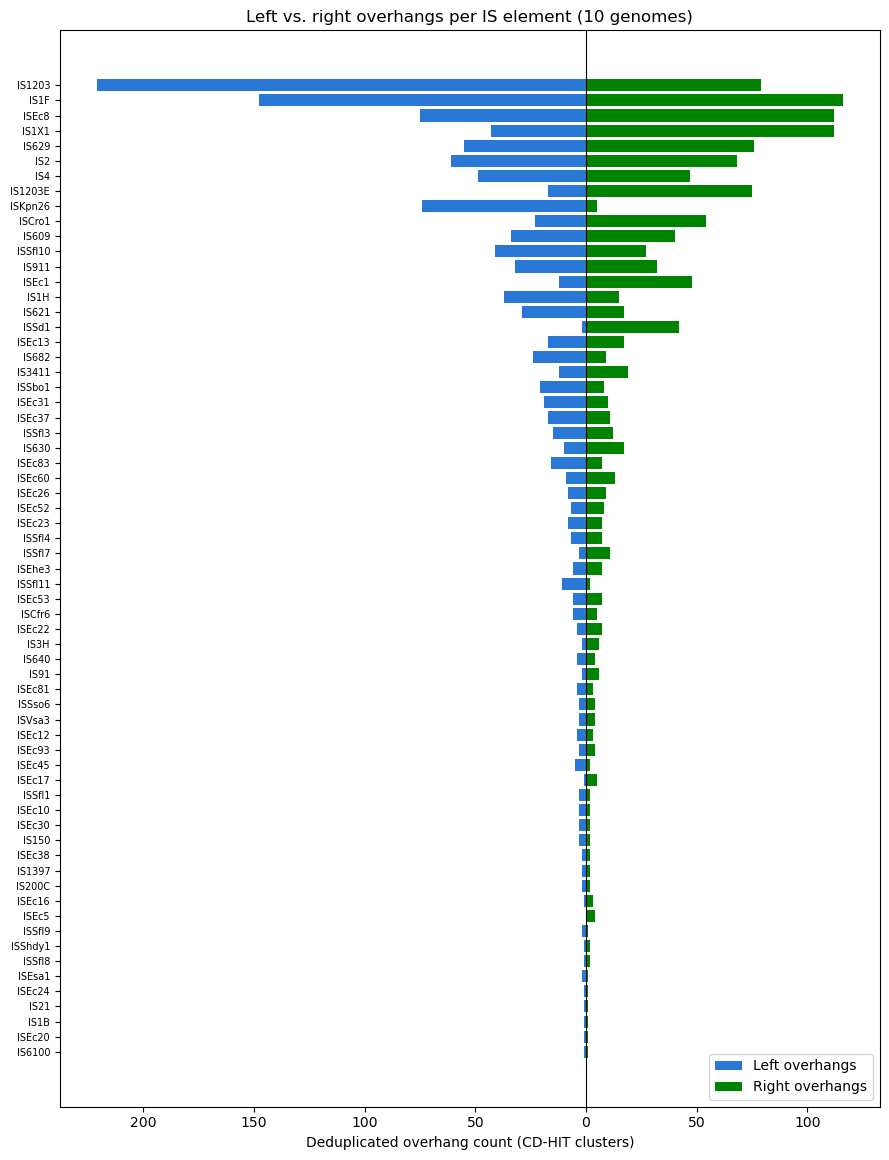

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_df = summary.reset_index().sort_values("total", ascending=True)  # ascending so largest ends up at top of barh
y = range(len(plot_df))

fig, ax = plt.subplots(figsize=(9, max(6, 0.18 * len(plot_df))))
ax.barh(y, -plot_df["left"], color="#2a78d6", label="Left overhangs")
ax.barh(y, plot_df["right"], color="#008300", label="Right overhangs")

ax.set_yticks(y)
ax.set_yticklabels(plot_df["is_element"], fontsize=7)
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(int(x))}"))  # left side is negative, show magnitudes
ax.set_xlabel("Deduplicated overhang count (CD-HIT clusters)")
ax.set_title(f"Left vs. right overhangs per IS element ({len(accessions)} genomes)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

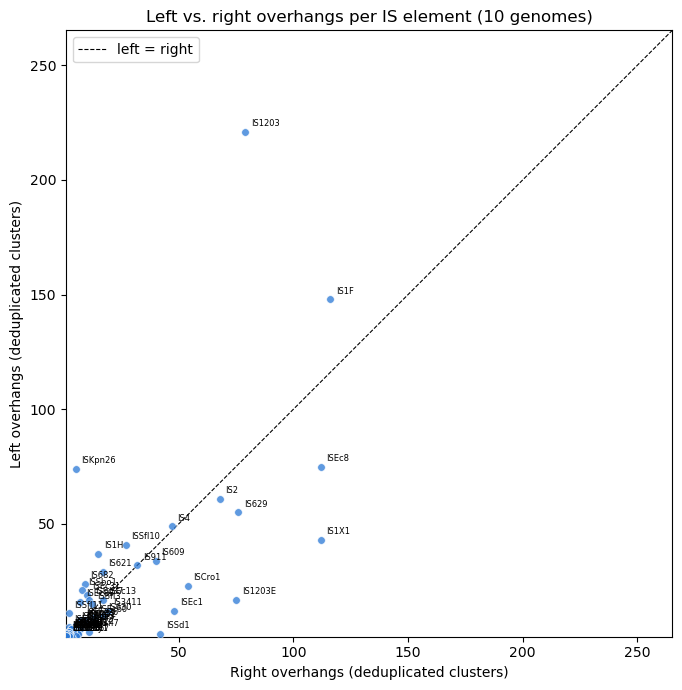

In [14]:
# turn above plot into a dot plot of right vs left clusters
import matplotlib.pyplot as plt

plot_df = summary.reset_index()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    plot_df["right"], plot_df["left"],
    s=30, color="#2a78d6", alpha=0.75, edgecolor="white", linewidth=0.5, zorder=3,
)

# y = x reference line -- points above it have more left overhangs, below have more right
max_val = max(plot_df["right"].max(), plot_df["left"].max())
lims = [0.8, max_val * 1.2]
ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--", zorder=1, label="left = right")

# label every IS element
for _, row in plot_df.iterrows():
    ax.annotate(
        row["is_element"], (row["right"], row["left"]),
        fontsize=6, xytext=(4, 4), textcoords="offset points",
    )

# ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Right overhangs (deduplicated clusters)")
ax.set_ylabel("Left overhangs (deduplicated clusters)")
ax.set_title(f"Left vs. right overhangs per IS element ({len(accessions)} genomes)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


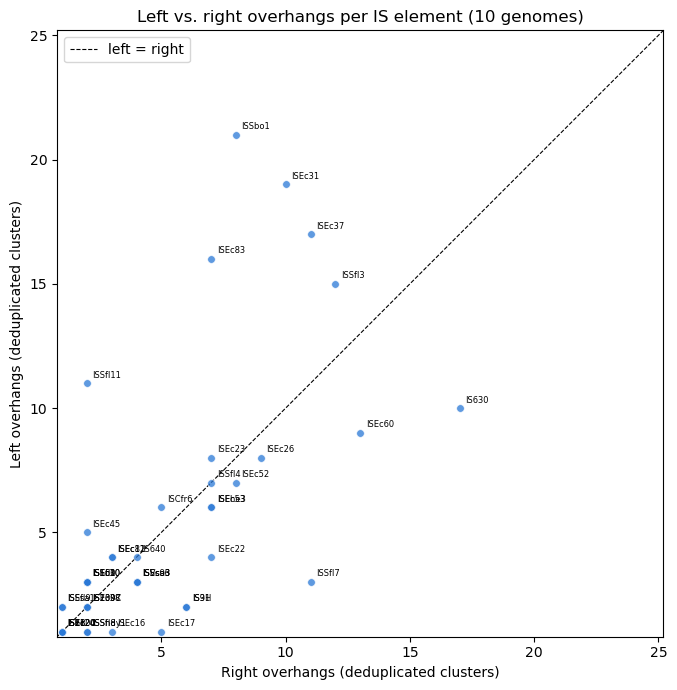

In [15]:
# turn above plot into a dot plot of right vs left clusters
import matplotlib.pyplot as plt

summary = summary[summary["total"]<30]

plot_df = summary.reset_index()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    plot_df["right"], plot_df["left"],
    s=30, color="#2a78d6", alpha=0.75, edgecolor="white", linewidth=0.5, zorder=3,
)

# y = x reference line -- points above it have more left overhangs, below have more right
max_val = max(plot_df["right"].max(), plot_df["left"].max())
lims = [0.8, max_val * 1.2]
ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--", zorder=1, label="left = right")

# label every IS element
for _, row in plot_df.iterrows():
    ax.annotate(
        row["is_element"], (row["right"], row["left"]),
        fontsize=6, xytext=(4, 4), textcoords="offset points",
    )

# ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Right overhangs (deduplicated clusters)")
ax.set_ylabel("Left overhangs (deduplicated clusters)")
ax.set_title(f"Left vs. right overhangs per IS element ({len(accessions)} genomes)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


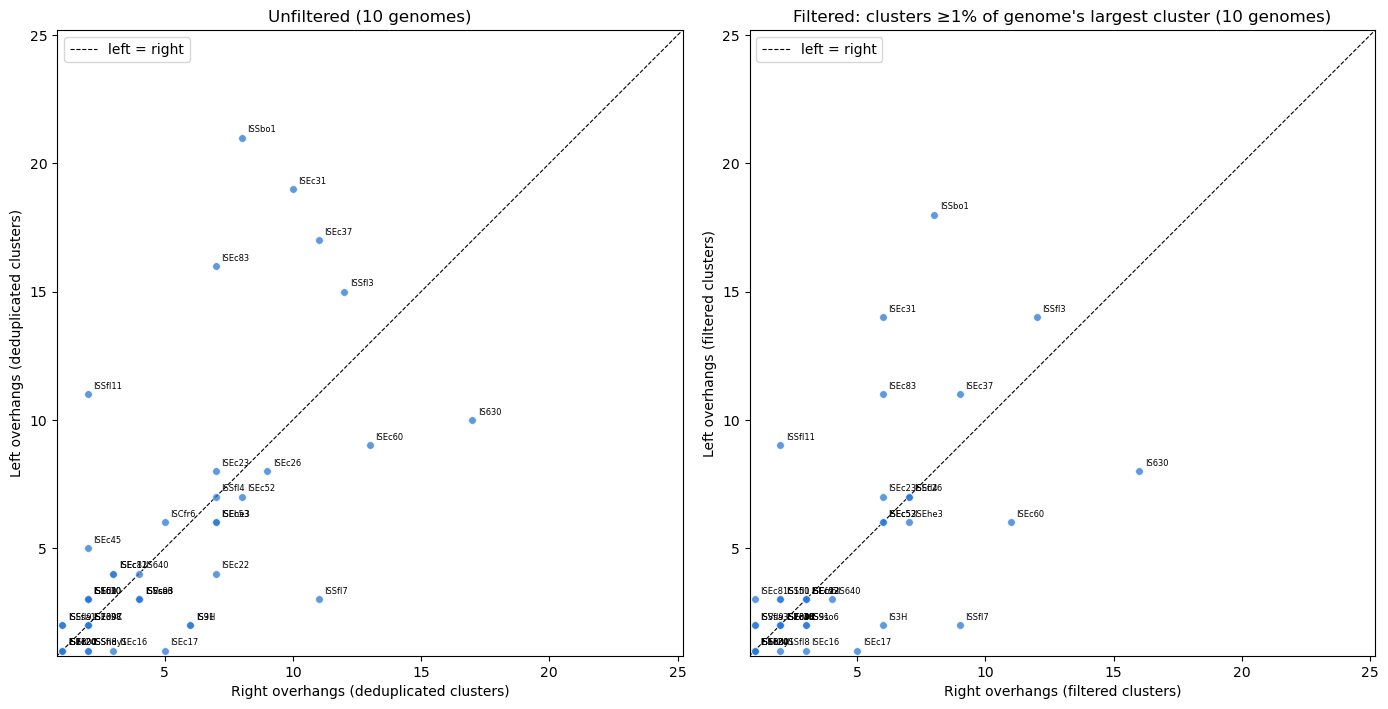

In [26]:
# side-by-side dot plots: left = unfiltered clusters, right = clusters filtered
# to >=1% of the largest cluster found anywhere in that genome
#
# both panels are derived from the same single pass over every genome's
# .clstr files, so they can't drift apart -- the only difference is whether
# the 1% threshold is applied. Also restricted to IS elements with a low
# total unfiltered cluster count (<30), same subset on both panels, and both
# panels share the same axis scale so they're directly comparable.
import sys
sys.path.insert(0, "/home/hua575/baymlab/mapping/scripts")
from combine_cdhit_clusters import parse_clusters
import matplotlib.pyplot as plt

all_rows = []
filtered_rows = []
for accession in accessions:
    manifest_path = CDHIT_ROOT / accession / f"{accession}.cdhit_manifest.tsv"
    if not manifest_path.exists():
        continue
    manifest = pd.read_csv(manifest_path, sep="\t")

    genome_clusters = []  # (is_element, side, cluster_size)
    for _, row in manifest.iterrows():
        clusters = parse_clusters(Path(row["clstr_path"]))
        for cluster in clusters:
            genome_clusters.append((row["is_element"], row["side"], len(cluster["members"])))

    genome_max = max(size for _, _, size in genome_clusters)
    threshold = 0.01 * genome_max

    all_counts = {}
    kept_counts = {}
    for is_element, side, size in genome_clusters:
        key = (is_element, side)
        all_counts[key] = all_counts.get(key, 0) + 1
        if size >= threshold:
            kept_counts[key] = kept_counts.get(key, 0) + 1

    for (is_element, side), n in all_counts.items():
        all_rows.append({"is_element": is_element, "side": side, "n_clusters": n})
    for (is_element, side), n in kept_counts.items():
        filtered_rows.append({"is_element": is_element, "side": side, "n_clusters": n})


def build_summary(rows):
    s = (
        pd.DataFrame(rows)
        .groupby(["is_element", "side"])["n_clusters"]
        .sum()
        .unstack("side", fill_value=0)
    )
    for side in ("left", "right"):
        if side not in s.columns:
            s[side] = 0
    s["total"] = s["left"] + s["right"]
    return s


true_summary = build_summary(all_rows)
filtered_summary = build_summary(filtered_rows)

# restrict both panels to the same low-count IS elements (total < 30,
# judged on the unfiltered counts so the cutoff means the same thing for both)
low_count_elements = true_summary[true_summary["total"] < 30].index
true_summary = true_summary.loc[low_count_elements]
filtered_summary = filtered_summary.reindex(low_count_elements, fill_value=0)


def plot_dot(ax, plot_df, title, xlabel, ylabel, lims):
    ax.scatter(
        plot_df["right"], plot_df["left"],
        s=30, color="#2a78d6", alpha=0.75, edgecolor="white", linewidth=0.5, zorder=3,
    )
    ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--", zorder=1, label="left = right")

    for _, row in plot_df.iterrows():
        ax.annotate(
            row["is_element"], (row["right"], row["left"]),
            fontsize=6, xytext=(4, 4), textcoords="offset points",
        )

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper left")


# shared axis limits computed across both panels, so they're on the same scale
max_val = max(
    true_summary["right"].max(), true_summary["left"].max(),
    filtered_summary["right"].max(), filtered_summary["left"].max(),
)
lims = [0.8, max_val * 1.2]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_dot(
    axes[0], true_summary.reset_index(),
    f"Unfiltered ({len(accessions)} genomes)",
    "Right overhangs (deduplicated clusters)",
    "Left overhangs (deduplicated clusters)",
    lims,
)
plot_dot(
    axes[1], filtered_summary.reset_index(),
    f"Filtered: clusters \u22651% of genome's largest cluster ({len(accessions)} genomes)",
    "Right overhangs (filtered clusters)",
    "Left overhangs (filtered clusters)",
    lims,
)

plt.tight_layout()
plt.show()


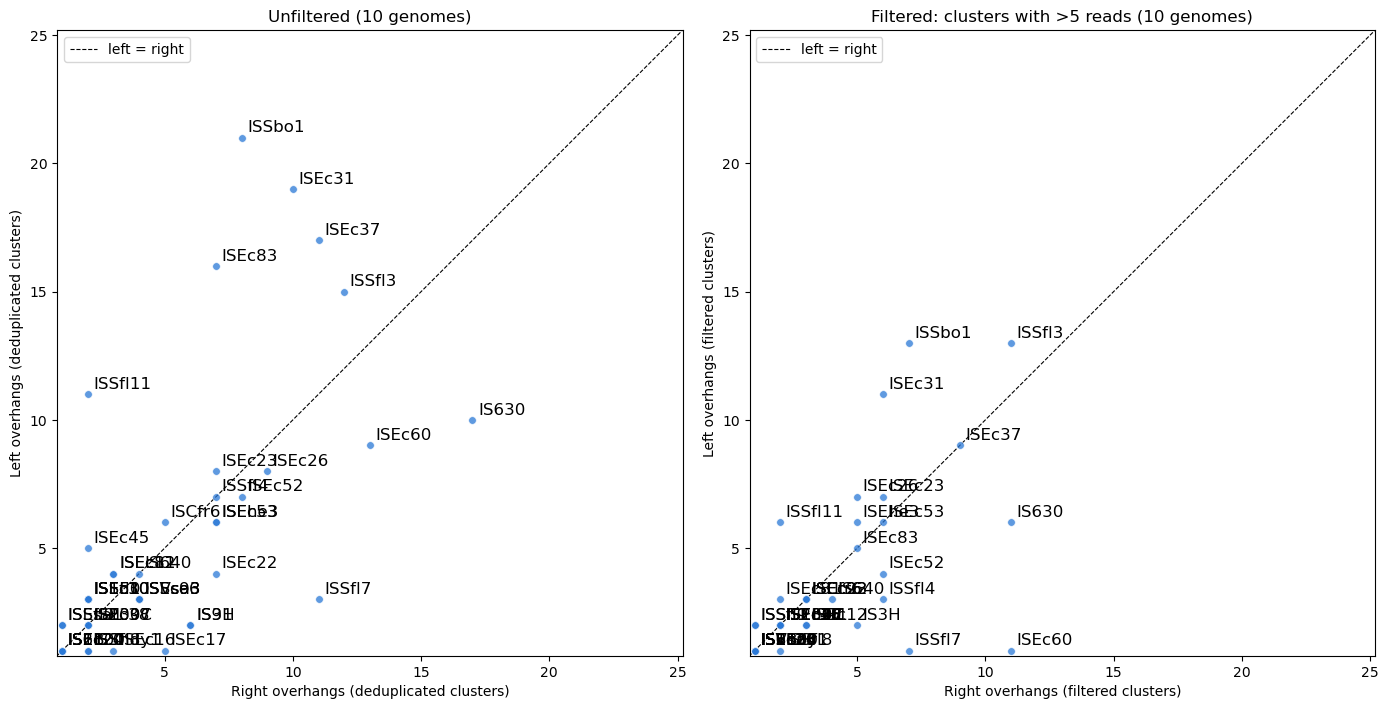

In [38]:
# filter out clusters containing less than 5 reads
# side-by-side dot plots: left = unfiltered clusters, right = clusters with
# more than 5 reads
#
# both panels are derived from the same single pass over every genome's
# .clstr files, so they can't drift apart -- the only difference is whether
# the >5-read filter is applied. Also restricted to IS elements with a low
# total unfiltered cluster count (<30), same subset on both panels, and both
# panels share the same axis scale so they're directly comparable.
import sys
sys.path.insert(0, "/home/hua575/baymlab/mapping/scripts")
from combine_cdhit_clusters import parse_clusters
import matplotlib.pyplot as plt

MIN_CLUSTER_SIZE = 5  # clusters with this many reads or fewer are dropped

all_rows = []
filtered_rows = []
for accession in accessions:
    manifest_path = CDHIT_ROOT / accession / f"{accession}.cdhit_manifest.tsv"
    if not manifest_path.exists():
        continue
    manifest = pd.read_csv(manifest_path, sep="\t")

    genome_clusters = []  # (is_element, side, cluster_size)
    for _, row in manifest.iterrows():
        clusters = parse_clusters(Path(row["clstr_path"]))
        for cluster in clusters:
            genome_clusters.append((row["is_element"], row["side"], len(cluster["members"])))

    all_counts = {}
    kept_counts = {}
    for is_element, side, size in genome_clusters:
        key = (is_element, side)
        all_counts[key] = all_counts.get(key, 0) + 1
        if size > MIN_CLUSTER_SIZE:
            kept_counts[key] = kept_counts.get(key, 0) + 1

    for (is_element, side), n in all_counts.items():
        all_rows.append({"is_element": is_element, "side": side, "n_clusters": n})
    for (is_element, side), n in kept_counts.items():
        filtered_rows.append({"is_element": is_element, "side": side, "n_clusters": n})


def build_summary(rows):
    s = (
        pd.DataFrame(rows)
        .groupby(["is_element", "side"])["n_clusters"]
        .sum()
        .unstack("side", fill_value=0)
    )
    for side in ("left", "right"):
        if side not in s.columns:
            s[side] = 0
    s["total"] = s["left"] + s["right"]
    return s


true_summary = build_summary(all_rows)
filtered_summary = build_summary(filtered_rows)

# restrict both panels to the same low-count IS elements (total < 30,
# judged on the unfiltered counts so the cutoff means the same thing for both)
low_count_elements = true_summary[true_summary["total"] < 30].index
true_summary = true_summary.loc[low_count_elements]
filtered_summary = filtered_summary.reindex(low_count_elements, fill_value=0)


def plot_dot(ax, plot_df, title, xlabel, ylabel, lims):
    ax.scatter(
        plot_df["right"], plot_df["left"],
        s=30, color="#2a78d6", alpha=0.75, edgecolor="white", linewidth=0.5, zorder=3,
    )
    ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--", zorder=1, label="left = right")

    for _, row in plot_df.iterrows():
        ax.annotate(
            row["is_element"], (row["right"], row["left"]),
            fontsize=12, xytext=(4, 4), textcoords="offset points",
        )

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper left")


# shared axis limits computed across both panels, so they're on the same scale
max_val = max(
    true_summary["right"].max(), true_summary["left"].max(),
    filtered_summary["right"].max(), filtered_summary["left"].max(),
)
lims = [0.8, max_val * 1.2]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_dot(
    axes[0], true_summary.reset_index(),
    f"Unfiltered ({len(accessions)} genomes)",
    "Right overhangs (deduplicated clusters)",
    "Left overhangs (deduplicated clusters)",
    lims,
)
plot_dot(
    axes[1], filtered_summary.reset_index(),
    f"Filtered: clusters with >{MIN_CLUSTER_SIZE} reads ({len(accessions)} genomes)",
    "Right overhangs (filtered clusters)",
    "Left overhangs (filtered clusters)",
    lims,
)

plt.tight_layout()
plt.show()



5/10 genomes have IS1203 clusters with >= 5 reads: ['SRR8275060', 'SRR8456430', 'SRR8358288', 'SRR17932668', 'SRR15418931']


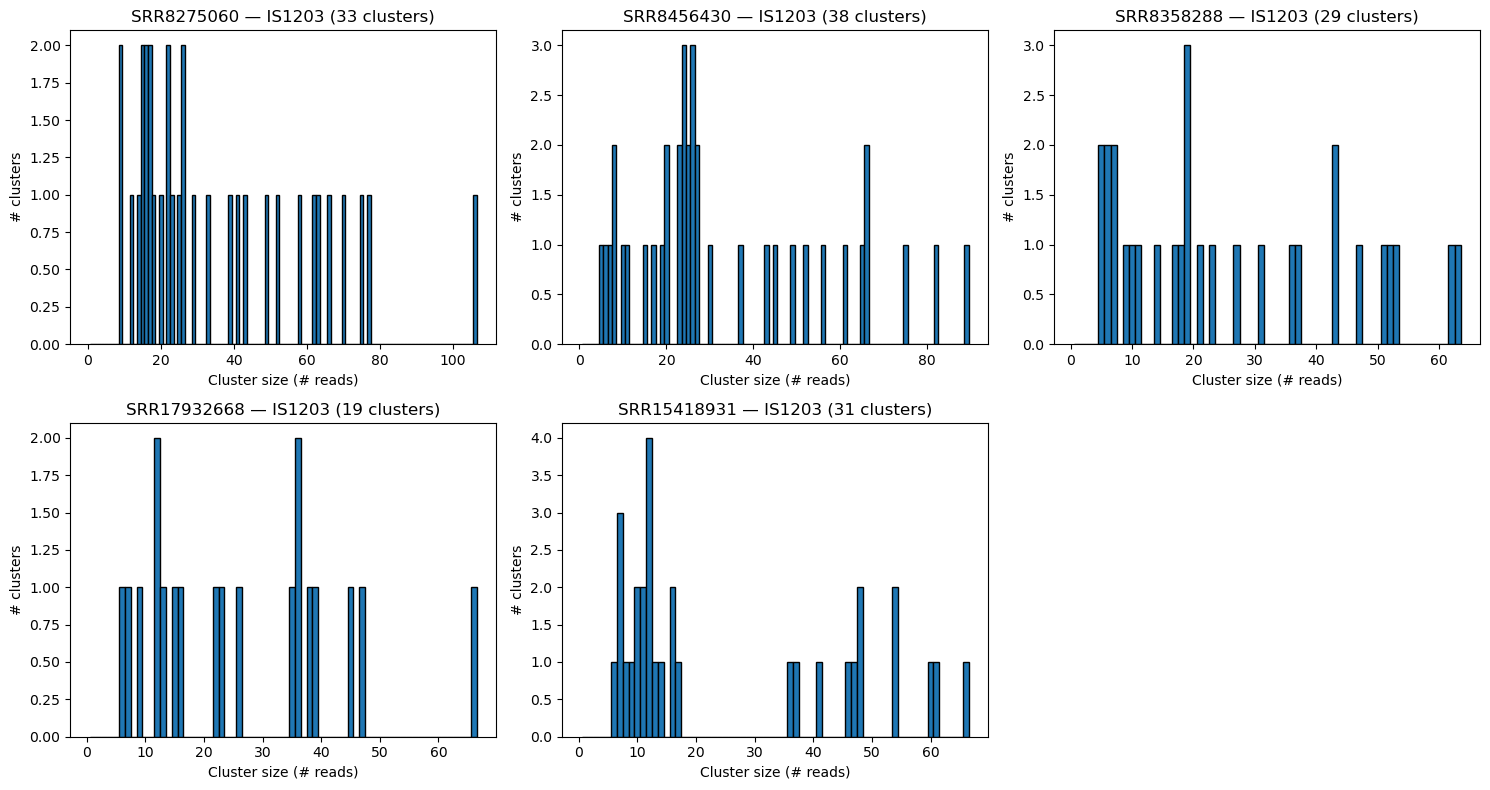

In [ ]:
# for each of the 10 genomes that has IS1203, plot the distribution of
# IS1203 cluster sizes (# reads per cluster, both sides combined),
# excluding clusters with fewer than 5 reads
import sys
sys.path.insert(0, "/home/hua575/baymlab/mapping/scripts")
from combine_cdhit_clusters import parse_clusters
import matplotlib.pyplot as plt

TARGET_IS = "IS1203"
MIN_CLUSTER_SIZE = 5

genome_cluster_sizes = {}  # accession -> list of cluster sizes
for accession in accessions:
    manifest_path = CDHIT_ROOT / accession / f"{accession}.cdhit_manifest.tsv"
    if not manifest_path.exists():
        continue
    manifest = pd.read_csv(manifest_path, sep="\t")
    is_rows = manifest[manifest["is_element"] == TARGET_IS]
    if is_rows.empty:
        continue

    sizes = []
    for _, row in is_rows.iterrows():
        clusters = parse_clusters(Path(row["clstr_path"]))
        sizes.extend(
            len(cluster["members"]) for cluster in clusters
            if len(cluster["members"]) >= MIN_CLUSTER_SIZE
        )
    if sizes:
        genome_cluster_sizes[accession] = sizes

print(f"{len(genome_cluster_sizes)}/{len(accessions)} genomes have {TARGET_IS} "
      f"clusters with >= {MIN_CLUSTER_SIZE} reads: {list(genome_cluster_sizes)}")

n = len(genome_cluster_sizes)
ncols = min(3, n)
nrows = -(-n // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for ax, (accession, sizes) in zip(axes.flat, genome_cluster_sizes.items()):
    max_size = max(sizes)
    ax.hist(sizes, bins=range(1, max_size + 2), edgecolor="black", align="left")
    ax.set_xlabel("Cluster size (# reads)")
    ax.set_ylabel("# clusters")
    ax.set_title(f"{accession} \u2014 {TARGET_IS} ({len(sizes)} clusters)")

for ax in axes.flat[len(genome_cluster_sizes):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

5/10 genomes have IS1203 clusters with >= 5 reads: ['SRR8275060', 'SRR8456430', 'SRR8358288', 'SRR17932668', 'SRR15418931']


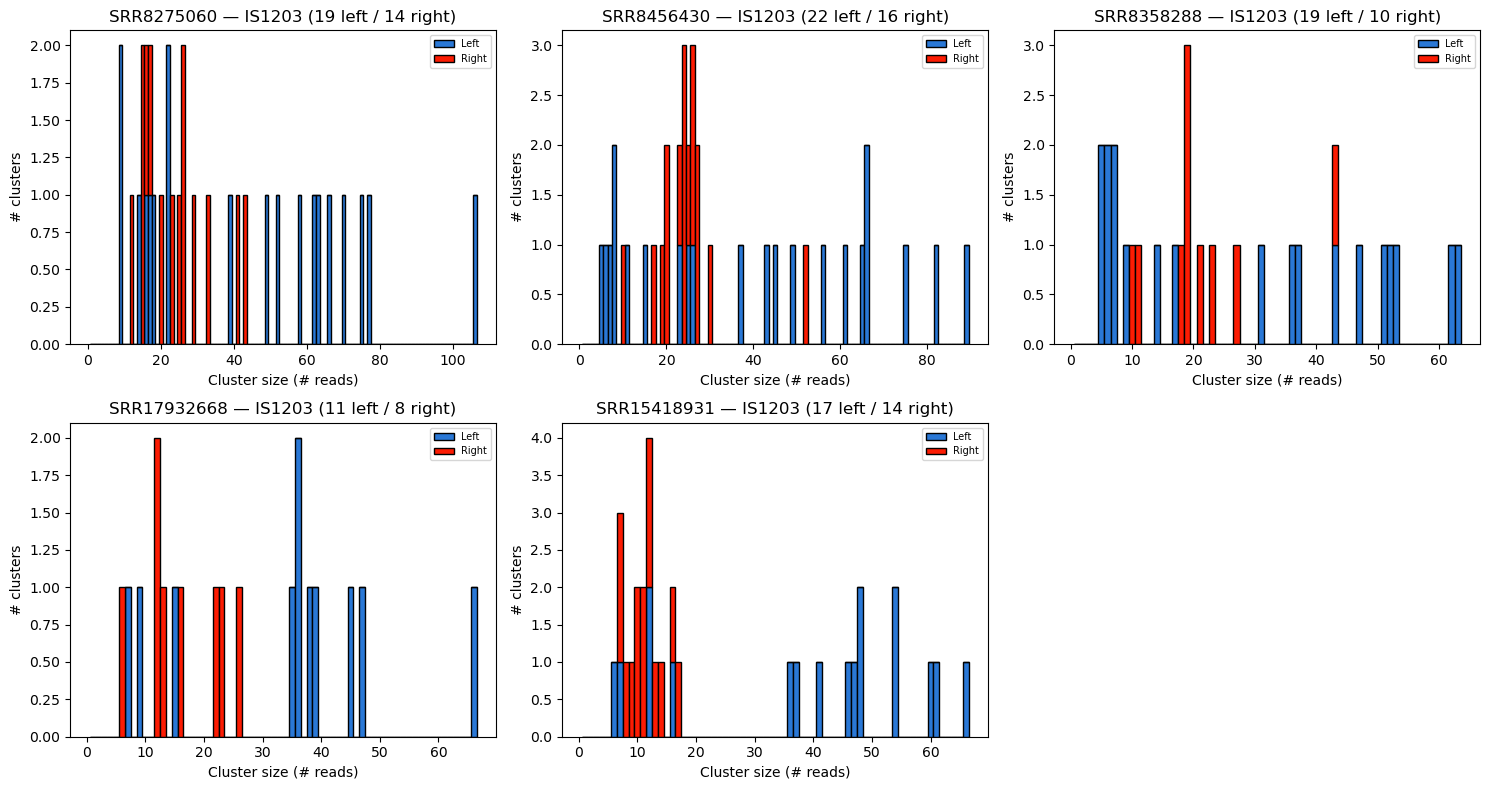

In [41]:
# for each of the 10 genomes that has IS1203, plot the distribution of
# IS1203 cluster sizes (# reads per cluster), left and right stacked,
# excluding clusters with fewer than 5 reads
import sys
sys.path.insert(0, "/home/hua575/baymlab/mapping/scripts")
from combine_cdhit_clusters import parse_clusters
import matplotlib.pyplot as plt

TARGET_IS = "IS1203"
MIN_CLUSTER_SIZE = 5

genome_cluster_sizes = {}  # accession -> {"left": [...], "right": [...]}
for accession in accessions:
    manifest_path = CDHIT_ROOT / accession / f"{accession}.cdhit_manifest.tsv"
    if not manifest_path.exists():
        continue
    manifest = pd.read_csv(manifest_path, sep="\t")
    is_rows = manifest[manifest["is_element"] == TARGET_IS]
    if is_rows.empty:
        continue

    sides = {"left": [], "right": []}
    for _, row in is_rows.iterrows():
        clusters = parse_clusters(Path(row["clstr_path"]))
        sizes = [
            len(cluster["members"]) for cluster in clusters
            if len(cluster["members"]) >= MIN_CLUSTER_SIZE
        ]
        sides[row["side"]].extend(sizes)

    if sides["left"] or sides["right"]:
        genome_cluster_sizes[accession] = sides

print(f"{len(genome_cluster_sizes)}/{len(accessions)} genomes have {TARGET_IS} "
      f"clusters with >= {MIN_CLUSTER_SIZE} reads: {list(genome_cluster_sizes)}")

n = len(genome_cluster_sizes)
ncols = min(3, n)
nrows = -(-n // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for ax, (accession, sides) in zip(axes.flat, genome_cluster_sizes.items()):
    all_sizes = sides["left"] + sides["right"]
    max_size = max(all_sizes)
    bins = range(1, max_size + 2)

    ax.hist(
        [sides["left"], sides["right"]],
        bins=bins, align="left", stacked=True,
        color=["#2a78d6", "#fc1c03"], edgecolor="black",
        label=["Left", "Right"],
    )

    ax.set_xlabel("Cluster size (# reads)")
    ax.set_ylabel("# clusters")
    ax.set_title(f"{accession} \u2014 {TARGET_IS} "
                 f"({len(sides['left'])} left / {len(sides['right'])} right)")
    ax.legend(fontsize=7)

for ax in axes.flat[len(genome_cluster_sizes):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


# July 22, 2026
* mapping cluster representatives to reference genomes

In [1]:
import pandas as pd
genome_acc = "SRR8275060"
insertion_seq = "ISEc8"
# for a specific member out of a multi-file zip:
import zipfile
with zipfile.ZipFile(f"../atb/downstream_analysis/random10_clusters_blasted/{genome_acc}.zip") as z:
    df1 = pd.read_csv(z.open(f"{insertion_seq}.tsv"), sep="\t")

In [29]:
import pandas as pd
genome_acc = "SRR8275060"
insertion_seq = "IS1203"
# for a specific member out of a multi-file zip:
import zipfile
with zipfile.ZipFile(f"../atb/downstream_analysis/random10_clusters_blasted/{genome_acc}.zip") as z:
    df2 = pd.read_csv(z.open(f"{insertion_seq}.tsv"), sep="\t")

In [19]:
import pandas as pd
genome_acc = "SRR14993593"
insertion_seq = "IS1F"
# for a specific member out of a multi-file zip:
import zipfile
with zipfile.ZipFile(f"/n/scratch/users/h/hua575/atb_filtered/gene_disruption/{genome_acc}.zip") as z:
    df3 = pd.read_csv(z.open(f"{insertion_seq}.tsv"), sep="\t")

In [4]:
import pandas as pd
import zipfile

In [20]:
def load_sample(genome_acc, base_dir="../atb/downstream_analysis/random10_clusters_blasted"):
    with zipfile.ZipFile(f"{base_dir}/{genome_acc}.zip") as z:
        dfs = [pd.read_csv(z.open(name), sep="\t") for name in z.namelist()]
    return pd.concat(dfs, ignore_index=True)

rand_df_1 = load_sample("SRR14993593")

In [21]:
def load_sample(genome_acc, base_dir="/n/scratch/users/h/hua575/atb_filtered/gene_disruption"):
    with zipfile.ZipFile(f"{base_dir}/{genome_acc}.zip") as z:
        dfs = [pd.read_csv(z.open(name), sep="\t") for name in z.namelist()]
    return pd.concat(dfs, ignore_index=True)

rand_df_2 = load_sample("SRR3000442")